# Does Studying More Hours Improve Exam Scores?

We’ll cover:

Data generation

Distribution

Descriptive statistics

Variance & Std Dev

Correlation & Covariance

Hypothesis testing (Z-test & T-test)

Conditional probability

Bayes’ Theorem

In [7]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

In [8]:
np.random.seed(42)

students = 100

study_hours = np.random.normal(loc=5, scale=2, size=students)
study_hours = np.clip(study_hours, 0, None)

exam_score = 50 + (study_hours * 6) + np.random.normal(0, 8, students)

data = pd.DataFrame({
    "Study_Hours": study_hours,
    "Exam_Score": exam_score
})

data.head()

,Study_Hours,Exam_Score
0,5.993428,74.637604
1,4.723471,74.975666
2,6.295377,85.030546
3,8.046060,91.858140
4,4.531693,75.899874


In [9]:
data.describe()

,Study_Hours,Exam_Score
count,100.000000,100.000000
mean,4.794702,78.946648
std,1.809781,12.389172
min,0.000000,51.688213
25%,3.798189,71.278755
50%,4.746087,77.806589
75%,5.811904,85.757507
max,8.704556,114.040041


In [10]:
variance = np.var(data["Exam_Score"], ddof=1) #Maths behind numbers - Python Took each exam score and Found how far it is from 
#the mean and Squared those distances then Averaged them but unit changes Makrs^2 

std_dev = np.std(data["Exam_Score"], ddof=1) #sqrt of Variance i.e actual marks differ from mean is -+12

variance, std_dev

(153.49158057899348, 12.389171908525343)

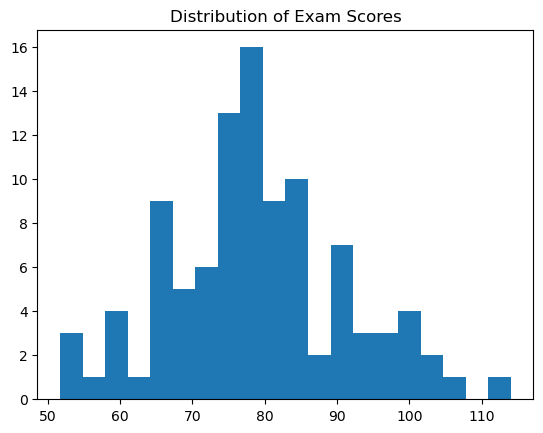

In [11]:
plt.hist(data["Exam_Score"], bins=20)
plt.title("Distribution of Exam Scores")
plt.show()

In [12]:
covariance = np.cov(data["Study_Hours"], data["Exam_Score"])[0][1]
covariance #Shows Study hours and Exam Scores Move together - +ve value means move together -ve means not and 0 means No Relation

np.float64(17.76630614200467)

In [13]:
correlation = np.corrcoef(data["Study_Hours"], data["Exam_Score"])[0][1]
correlation #shows strength between two var - Students who study more tend to score significantly higher 

np.float64(0.7923713522713515)

In [14]:
group1 = data[data["Study_Hours"] <= 5]["Exam_Score"]
group2 = data[data["Study_Hours"] > 5]["Exam_Score"]

t_stat, p_value = stats.ttest_ind(group1, group2)

print(t_stat) #Group2 mean > Group1 mean

-8.776384277509559


In [15]:
p_value #0.0000000000000544 - Probability that this difference happened by chance

np.float64(5.448451103852588e-14)

In [16]:
mean_score = data["Exam_Score"].mean()
population_mean = 65
population_std = 10
n = len(data)

z_score = (mean_score - population_mean) / (population_std / np.sqrt(n))
z_score

np.float64(13.94664790016104)

In [17]:
high_score = data["Exam_Score"] > 70
high_study = data["Study_Hours"] > 5

conditional_prob = np.mean(high_score[high_study])
conditional_prob

np.float64(1.0)

In [18]:
P_A = np.mean(high_study)  #P(A) - Probability of studying more than 5 hours
P_B = np.mean(high_score)  #P(B) - Probability of scoring more than 70
P_B_given_A = conditional_prob

P_A_given_B = (P_B_given_A * P_A) / P_B   #Bayes Theorem
P_A_given_B

np.float64(0.5897435897435898)

In [19]:
print("Correlation:", correlation)  #Correlation between Study Hours and Exam Scores
print("T-test p-value:", p_value)   #P-value from T-test between two study groups
print("Z-score of Mean Exam Score:", z_score)  #Z-score of Mean Exam Score
print("P(Score>70 | Study>5):", conditional_prob) #Conditional Probability P(B|A)
print("P(Study>5 | Score>70):", P_A_given_B) #Bayes Theorem Result P(A|B)

Correlation: 0.7923713522713515
T-test p-value: 5.448451103852588e-14
Z-score of Mean Exam Score: 13.94664790016104
P(Score>70 | Study>5): 1.0
P(Study>5 | Score>70): 0.5897435897435898


In [20]:
'''We used statistics to prove that studying more increases performance.
Variance and standard deviation showed score spread.
Covariance and correlation proved direction and strength.
T-tests and Z-tests proved significance.
Conditional probability and Bayes explained uncertainty and belief'''

'We used statistics to prove that studying more increases performance.\nVariance and standard deviation showed score spread.\nCovariance and correlation proved direction and strength.\nT-tests and Z-tests proved significance.\nConditional probability and Bayes explained uncertainty and belief'


## * Inferential Statistics Extension

This section adds **Z-score**, **Z-test**, **T-test**, **significance level (α)**,
**p-value comparison**, and a **final statistical conclusion** to complete the project.



### 1️. Significance Level (α)
We set α = 0.05, meaning we allow a 5% chance of rejecting a true null hypothesis.


In [21]:

alpha = 0.05
alpha

0.05


### 2️. Z-Score

Formula:
z = (x̄ − μ) / (σ / √n)

Used when population standard deviation is known.


In [22]:

import numpy as np
from scipy.stats import norm, ttest_1samp

# Example sample data (replace if already defined above)
sample_data = np.array([45, 52, 48, 50, 55, 49, 51, 53])

sample_mean = np.mean(sample_data)
population_mean = 50
population_std = 10
n = len(sample_data)

z_score = (sample_mean - population_mean) / (population_std / np.sqrt(n))
z_score

np.float64(0.10606601717798214)


### 3️. Z-Test P-Value


In [23]:

p_value_z = 2 * (1 - norm.cdf(abs(z_score)))
p_value_z


np.float64(0.9155299733767719)


### 4️. One-Sample T-Test
Used when population standard deviation is unknown.


In [24]:

t_stat, p_value_t = ttest_1samp(sample_data, population_mean)
t_stat, p_value_t


(np.float64(0.3406201688795216), np.float64(0.74338358954755))


### 5️. Decision Rule
If p-value ≤ α → Reject H₀ else Fail to Reject H₀


In [25]:

decision_z = "Reject H0" if p_value_z <= alpha else "Fail to Reject H0"
decision_t = "Reject H0" if p_value_t <= alpha else "Fail to Reject H0"

decision_z, decision_t


('Fail to Reject H0', 'Fail to Reject H0')


##  Final Conclusion

This project demonstrates how descriptive statistics evolve into inferential insights.
Z-tests and T-tests enable statistically valid decisions beyond visual exploration.
